In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.semi_supervised import LabelPropagation
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Paso 1: Cargar y preparar el dataset Poker Hand sin labels
df = pd.read_csv('poker-hand-all-no-label.csv')
X = df.values  # Shape: (~1M, 10)
print(f"Dataset cargado: {X.shape[0]} ejemplos, {X.shape[1]} features.")
print(df.head())  # Verifica headers

Dataset cargado: 1025010 ejemplos, 10 features.
   S1  C1  S2  C2  S3  C3  S4  C4  S5  C5
0   1  10   1  11   1  13   1  12   1   1
1   2  11   2  13   2  10   2  12   2   1
2   3  12   3  11   3  13   3  10   3   1
3   4  10   4  11   4   1   4  13   4  12
4   4   1   4  13   4  12   4  11   4  10


In [2]:
# === OPTIMIZACIÓN: Submuestreo para velocidad (crucial para LabelPropagation) ===
# Usa 20k para demo rápida (<1min); descomenta abajo para full (lento/riesgo RAM)
subsample_size = 20000
if len(X) > subsample_size:
    sub_idx = np.random.choice(len(X), subsample_size, replace=False)
    X = X[sub_idx]
    print(f"Submuestreado a {len(X)} ejemplos para velocidad (ajusta subsample_size si necesitas más).")
# Descomenta para full: # subsample_size = len(X)

# Escala los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Número de clusters (para poker, ~10 tipos de manos)
n_clusters = 10


Submuestreado a 20000 ejemplos para velocidad (ajusta subsample_size si necesitas más).



--- Aprendizaje Semisupervisado ---


C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:322: ConvergenceWarning: max_iter=100 was reached without convergence.
  warnings.warn(


Silhouette Score Semisupervisado: 0.019
Porcentaje de datos etiquetados final: 100.0%


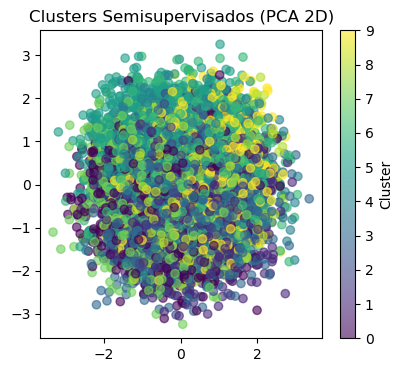

In [ ]:
# === APRENDIZAJE SEMISUPERVISADO ===
print("\n--- Aprendizaje Semisupervisado ---")
# Genera pseudo-labels iniciales: KMeans en subconjunto pequeño (2% para speed)
prop_labeled = 0.02  # 2% inicial (ajusta a 0.05+ si más labels)
n_labeled = int(prop_labeled * len(X_scaled))

# Split índices primero para consistencia
idx_train, idx_test = train_test_split(np.arange(len(X_scaled)), train_size=n_labeled, random_state=42)
X_init = X_scaled[idx_train]

# Pseudo-labels con KMeans
kmeans_init = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
pseudo_labels = kmeans_init.fit_predict(X_init)

# Prepara labels: -1 para unlabeled
y_semi = np.full(len(X_scaled), -1)
y_semi[idx_train] = pseudo_labels  # ¡Fijo: asigna a índices correctos!

# Aplica LabelPropagation (sin random_state, kernel RBF para no linealidades)
lp_model = LabelPropagation(kernel='rbf', gamma=20, max_iter=200)  # ¡Fijo: sin random_state!
lp_model.fit(X_scaled, y_semi)

# Obtén labels propagados
labels_semi = lp_model.transduction_
# Filtra -1 para score (si quedan unlabeled)
valid_mask = labels_semi != -1
n_valid = np.sum(valid_mask)
if n_valid > n_clusters:  # Mínimo para sil
    sil_semi = silhouette_score(X_scaled[valid_mask], labels_semi[valid_mask])
else:
    sil_semi = 0
    print("Advertencia: Pocos datos propagados; ajusta gamma o prop_labeled.")
print(f"Silhouette Score Semisupervisado: {sil_semi:.3f}")
print(f"Porcentaje de datos etiquetados final: {n_valid / len(X_scaled) * 100:.1f}%")

# Visualización (PCA 2D, submuestra 10k para plot rápido)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plot_sub_size = min(10000, len(X_pca))  # No más que disponible
plot_idx = np.random.choice(len(X_pca), plot_sub_size, replace=False) if len(X_pca) > plot_sub_size else np.arange(len(X_pca))
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[plot_idx, 0], X_pca[plot_idx, 1], c=labels_semi[plot_idx], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('Clusters Semisupervisados (PCA 2D)')
plt.show()


--- Aprendizaje Activo ---
Ronda 1/5


C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


  Silhouette: 0.094, Labeled: 200
  Queries agregados: 50
Ronda 2/5
  Silhouette: 0.017, Labeled: 250
  Queries agregados: 50
Ronda 3/5


C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  Silhouette: -0.012, Labeled: 300
  Queries agregados: 50
Ronda 4/5
  Silhouette: -0.025, Labeled: 350
  Queries agregados: 50
Ronda 5/5


C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\saygu\anaconda3\envs\SIS420\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


  Silhouette: -0.031, Labeled: 400
  Queries agregados: 50

Silhouette Final Activo: -0.038
Total labeled: 450 (2.2%)


C:\Users\saygu\AppData\Local\Temp\ipykernel_17592\1329572094.py:72: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "go-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(range(1, len(sil_history)+1), sil_history, 'go-', marker='o')


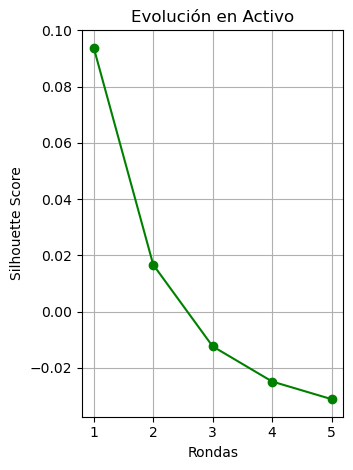


--- Comparación ---
Silhouette KMeans Puro: 0.069
Semisupervisado: 0.019 (delta: -0.050)
Activo Final: -0.038 (delta: -0.107)


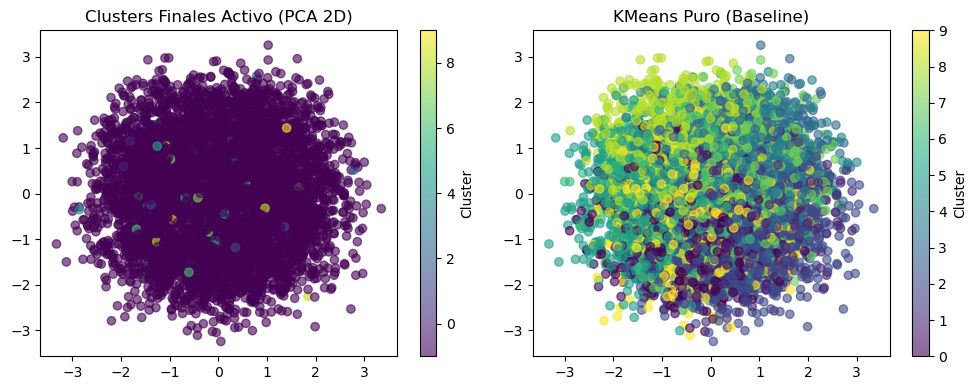

In [ ]:
# === APRENDIZAJE ACTIVO ===
print("\n--- Aprendizaje Activo ---")
# Inicia con pocos labels, itera queries (incertidumbre: cerca de boundaries)
n_init_labeled = 200  # Menos inicial para speed
n_query_per_round = 50  # Menos queries por ronda
n_rounds = 5  # Menos rondas
prop_sub_unlabeled = 0.1  # 10% de unlabeled para queries

y_active = np.full(len(X_scaled), -1)

# Labels iniciales: aleatorios + KMeans
init_idx = np.random.choice(len(X_scaled), n_init_labeled, replace=False)
kmeans_init_active = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
y_active[init_idx] = kmeans_init_active.fit_predict(X_scaled[init_idx])

sil_history = []

for round_num in range(n_rounds):
    print(f"Ronda {round_num + 1}/{n_rounds}")
    
    labeled_mask = y_active != -1
    unlabeled_mask = y_active == -1
    
    if np.sum(unlabeled_mask) == 0:
        print("Todos etiquetados.")
        break
    
    # Entrena KMeans en labeled actuales
    X_labeled = X_scaled[labeled_mask]
    y_labeled = y_active[labeled_mask]
    kmeans_current = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_current.fit(X_labeled)
    
    # Silhouette actual (solo labeled)
    unique_labels = np.unique(y_labeled)
    if len(unique_labels) > 1:
        sil_current = silhouette_score(X_labeled, y_labeled)
    else:
        sil_current = 0
    sil_history.append(sil_current)
    print(f"  Silhouette: {sil_current:.3f}, Labeled: {np.sum(labeled_mask)}")
    
    # Query: Incertidumbre (min dist a centroides, cerca de boundaries)
    n_sub_unlabeled = min(int(prop_sub_unlabeled * np.sum(unlabeled_mask)), 10000)  # Cap para speed
    if n_sub_unlabeled == 0:
        break
    sub_unlabeled_idx = np.random.choice(np.where(unlabeled_mask)[0], n_sub_unlabeled, replace=False)
    X_sub_unlabeled = X_scaled[sub_unlabeled_idx]
    
    dists_to_centers = np.min(kmeans_current.transform(X_sub_unlabeled), axis=1)
    # Query más inciertos (menores dists = cerca de decisión)
    query_sub_idx = np.argsort(dists_to_centers)[:n_query_per_round]
    query_global_idx = sub_unlabeled_idx[query_sub_idx]
    
    # "Etiqueta" con KMeans actual
    y_active[query_global_idx] = kmeans_current.predict(X_scaled[query_global_idx])
    print(f"  Queries agregados: {len(query_global_idx)}")
    
# Eval final
final_labeled_mask = y_active != -1
n_final = np.sum(final_labeled_mask)
unique_final = np.unique(y_active[final_labeled_mask])
if n_final > n_clusters and len(unique_final) > 1:
    sil_active_final = silhouette_score(X_scaled[final_labeled_mask], y_active[final_labeled_mask])
else:
    sil_active_final = 0
print(f"\nSilhouette Final Activo: {sil_active_final:.3f}")
print(f"Total labeled: {n_final} ({n_final / len(X_scaled) * 100:.1f}%)")

# Plot evolución
plt.subplot(1, 2, 2)
plt.plot(range(1, len(sil_history)+1), sil_history, 'go-', marker='o')
plt.xlabel('Rondas')
plt.ylabel('Silhouette Score')
plt.title('Evolución en Activo')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot final clusters
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
scatter_active = plt.scatter(X_pca[plot_idx, 0], X_pca[plot_idx, 1], c=y_active[plot_idx], cmap='viridis', alpha=0.6)
plt.colorbar(scatter_active, label='Cluster')
plt.title('Clusters Finales Activo (PCA 2D)')

# Baseline: KMeans puro
kmeans_pure = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_pure = kmeans_pure.fit_predict(X_scaled)
sil_pure = silhouette_score(X_scaled, labels_pure)
print(f"\n--- Comparación ---")
print(f"Silhouette KMeans Puro: {sil_pure:.3f}")
print(f"Semisupervisado: {sil_semi:.3f} (delta: {sil_semi - sil_pure:+.3f})")
print(f"Activo Final: {sil_active_final:.3f} (delta: {sil_active_final - sil_pure:+.3f})")

plt.subplot(1, 2, 2)
scatter_pure = plt.scatter(X_pca[plot_idx, 0], X_pca[plot_idx, 1], c=labels_pure[plot_idx], cmap='viridis', alpha=0.6)
plt.colorbar(scatter_pure, label='Cluster')
plt.title('KMeans Puro (Baseline)')
plt.tight_layout()
plt.show()